In [78]:
%pip install pandas matplotlib plotly seaborn

Note: you may need to restart the kernel to use updated packages.


In [79]:
import os
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Importazione dei dati


In [80]:
path="clean_datasets"

In [81]:
# Load datasets
try:
    df_actors = pd.read_csv(os.path.join(path, "df_actors.csv"))
    df_countries = pd.read_csv(os.path.join(path, "df_countries.csv"))
    df_crew = pd.read_csv(os.path.join(path, "df_crew.csv"))
    df_released_movies = pd.read_csv(os.path.join(path, "df_released_movies.csv"))
    df_unreleased_movies = pd.read_csv(os.path.join(path, "df_unreleased_movies.csv"))
    df_movies = pd.read_csv(os.path.join(path, "df_movies.csv"))
    df_languages = pd.read_csv(os.path.join(path, "df_languages.csv"))
    df_posters = pd.read_csv(os.path.join(path, "df_posters.csv"))
    df_releases = pd.read_csv(os.path.join(path, "df_releases.csv"))
    df_themes = pd.read_csv(os.path.join(path, "df_themes.csv"))
    df_genres = pd.read_csv(os.path.join(path, "df_genres.csv"))
    df_studios = pd.read_csv(os.path.join(path, "df_studios.csv"))
    df_tomatoes= pd.read_csv(os.path.join(path, "df_tomatoes.csv"))
    df_oscars = pd.read_csv(os.path.join(path, "df_oscars.csv"))
except Exception as e:
    print(e)

# **Analisi dei Dati**


## Trend di popolarità (rating) dei film nel tempo

- Come è cambiato il rating dei film nel tempo ?
- Quali sono state le cause di questo cambiamento?
- Quale potrebbe essere una spiegazione totale della situazione?


Analizzeremo come i film nel tempo abbiano variato di popolarità tramite il loro rating medio, cercando correlazioni con il genere, il paese ed eventuali altri fattori


In [82]:
df_released_movies.columns

Index(['id', 'name', 'date', 'tagline', 'description', 'minute', 'rating'], dtype='object')

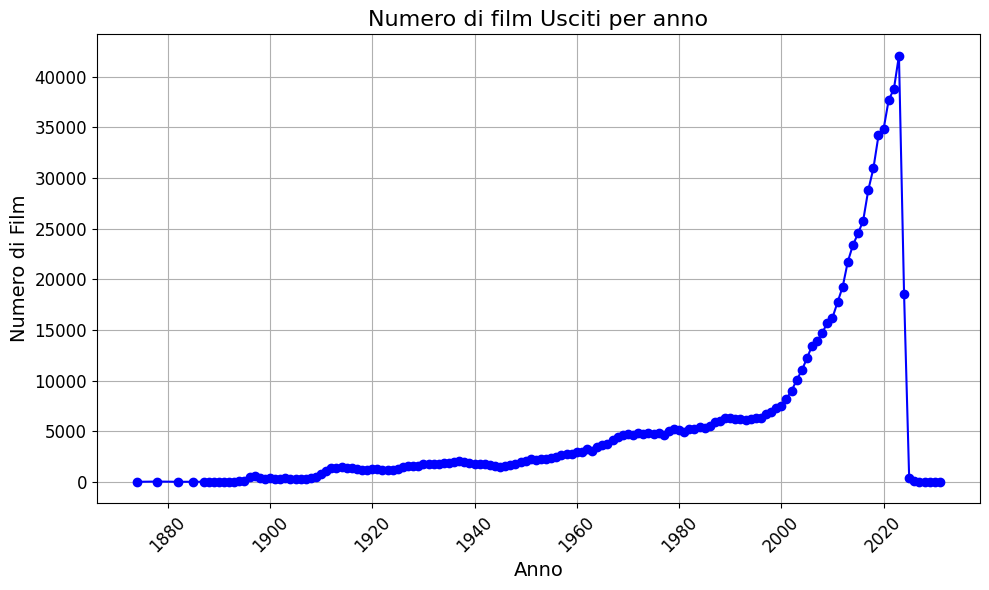

In [83]:
films_per_year = df_released_movies.groupby("date").size()
plt.figure(figsize=(10, 6))
plt.plot(films_per_year.index, films_per_year.values, marker='o', linestyle='-', color='blue', label="Numero di Film")

plt.title("Numero di film Usciti per anno", fontsize=16)
plt.xlabel("Anno", fontsize=14)
plt.ylabel("Numero di Film", fontsize=14)
plt.xticks(fontsize=12, rotation=45)
max_y = films_per_year.max()
yticks = list(range(0, max_y + 10, 5000))  
plt.yticks(yticks, fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

Vi è stato un chiaro incremento nel tempo nel numero di film prodotti per anno, fino ad un improvviso crollo, che possiamo attribuire probabilmente alla nascita e all'evoluzione del Covid degli anni recenti.
Ora possiamo analizzare come invece si è evoluta in media la valutazione de film nei diversi anni da parte del pubblico e successivamente da parte dei critici .


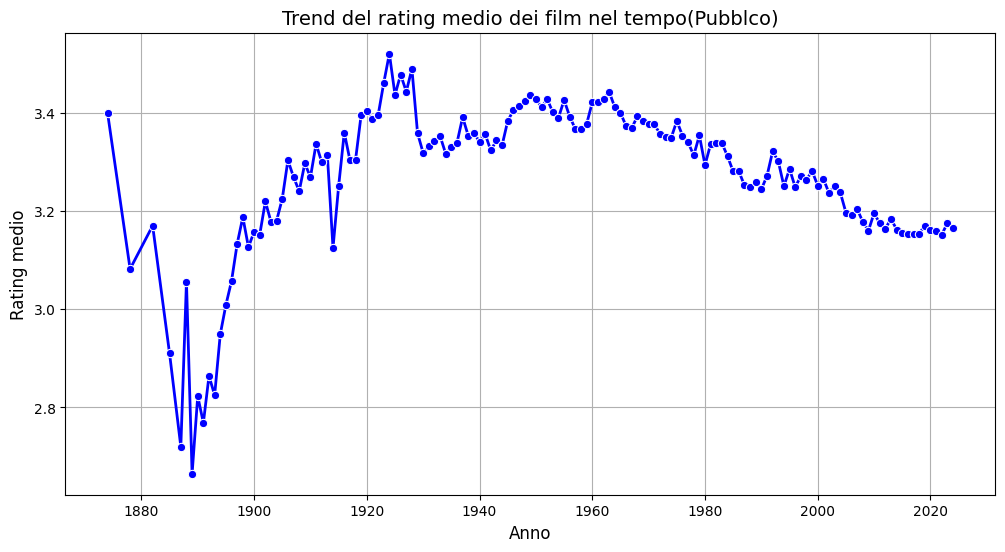

In [84]:
rating_trend = df_released_movies.groupby('date')['rating'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=rating_trend, x='date', y='rating', marker='o', linewidth=2, color='b')
plt.title("Trend del rating medio dei film nel tempo(Pubblco)", fontsize=14)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Rating medio", fontsize=12)
plt.grid(True)
plt.show()

Negli inizi degli anni tra il 1920 e il 1940 abbiamo un picco di rating medio, mentre da quel punto possiamo notare un lento calo nelle valutazioni effettuate dal pubblico.


In [85]:
df_tomatoes.dtypes

movie_title        object
critic_name        object
top_critic           bool
publisher_name     object
review_type        object
review_date        object
review_content     object
link               object
rating            float64
dtype: object

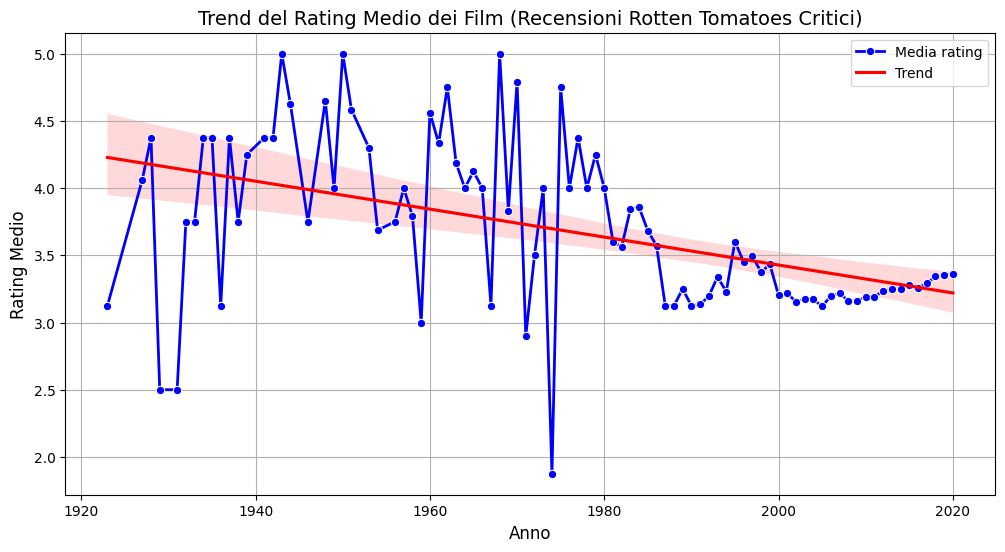

In [86]:
rating_trend = df_tomatoes.copy()

# Convert review_date to datetime
rating_trend['year'] = pd.to_datetime(rating_trend['review_date'], errors='coerce').dt.year

rating_trend = rating_trend[(rating_trend['year'] >= 1830) & (rating_trend['year'] <= 2025)]
rating_trend = rating_trend.groupby('year')['rating'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=rating_trend['year'], y=rating_trend['rating'], marker="o",linewidth=2, color='b', label="Media rating")
sns.regplot(x=rating_trend['year'], y=rating_trend['rating'], scatter=False, color="red", label="Trend")
plt.title("Trend del Rating Medio dei Film (Recensioni Rotten Tomatoes Critici)", fontsize=14)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Rating Medio", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

Possiamo notare come anche i rating dei critici siano stato in calo durante il tempo, fino ad una quasi stabilizzazione negli anni più recenti, questo però nota come i valori da parte dei critici siano diversi rispetto a quello del pubblico.
Quindi anche se in comune vi è il tranding verso il basso, i critici annualmente,in media, anche assegnato generalmente valori più alti come rating verso i film in uscita.
Perciò possiamo intuire che sia il pubblico che ha sviluppato un particolare per cui la popolarità dei film sia diminuita nel tempo.


Ci concentreremo principalmente sull'analisi dei rating del pubblico, per analizzare una valutazione più ampia.
Utiliziamo diversi boxplot per esplicitare la distribuzione del rating nel tempo.


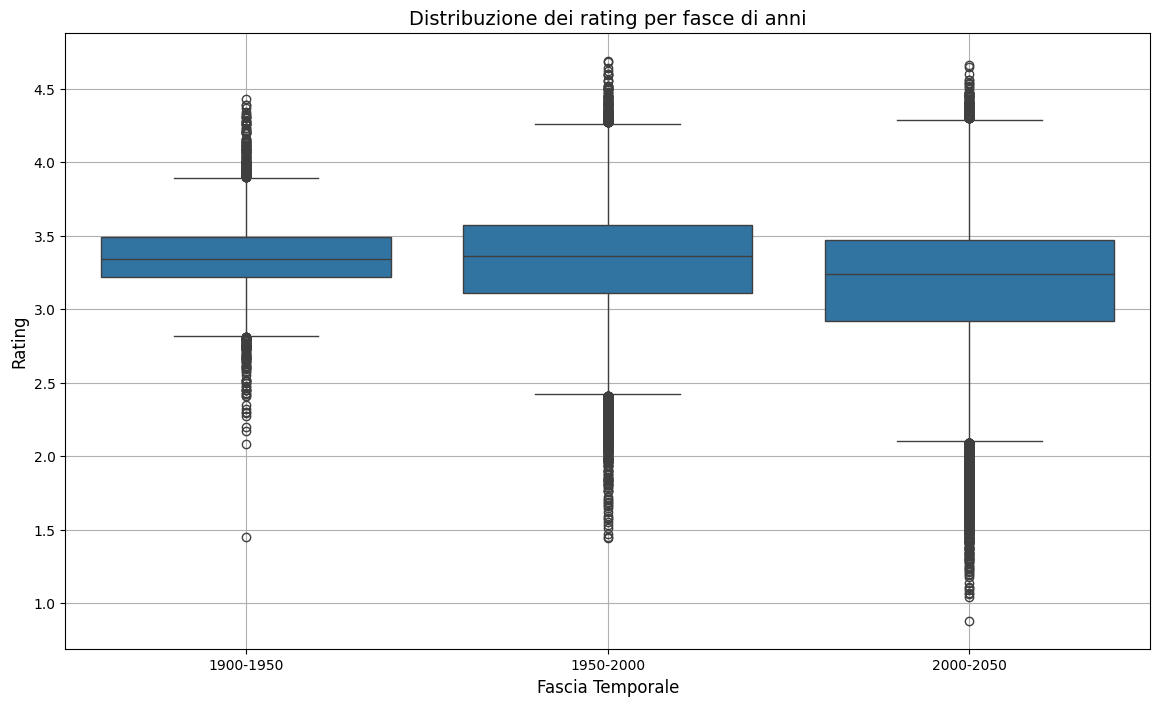

In [87]:
bins = [1900, 1950, 2000, 2050]  
labels = ["1900-1950", "1950-2000", "2000-2050"]
df_movies_year = df_released_movies.copy()
df_movies_year['year_range'] = pd.cut(df_released_movies['date'], bins=bins, labels=labels, right=False)

# Creare il box plot diviso per fasce di anni
plt.figure(figsize=(14,8))
sns.boxplot(data=df_movies_year, x='year_range', y='rating')
plt.title("Distribuzione dei rating per fasce di anni", fontsize=14)
plt.xlabel("Fascia Temporale", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.grid(True)
plt.show()

La mediana è rimasta molto simile in tutti e 3 i casi, quindi sappiamo che il rating mediano è rimasto abbastanza simile nel corso degli anni.
La larghezza del terzo box però, maggiore rispetto alla seconda e molto più grande della prima, indica come ci sia definitivamente una discrepanza di valutazione più netta nei film recenti, quindi abbiamo una diversità nella qualità percepita nei film.
Gli outlier negativi del periodo più recente indicano chiaramente voti negativi rispetto alla media generale.
Questo ci conferma quindi quello visto nella tabella superiore, dove abbiamo una riduzione della media dei voti


Proviamo a correlare i generi con i rating per vedere se c'è un qualche collegamento tra i due.


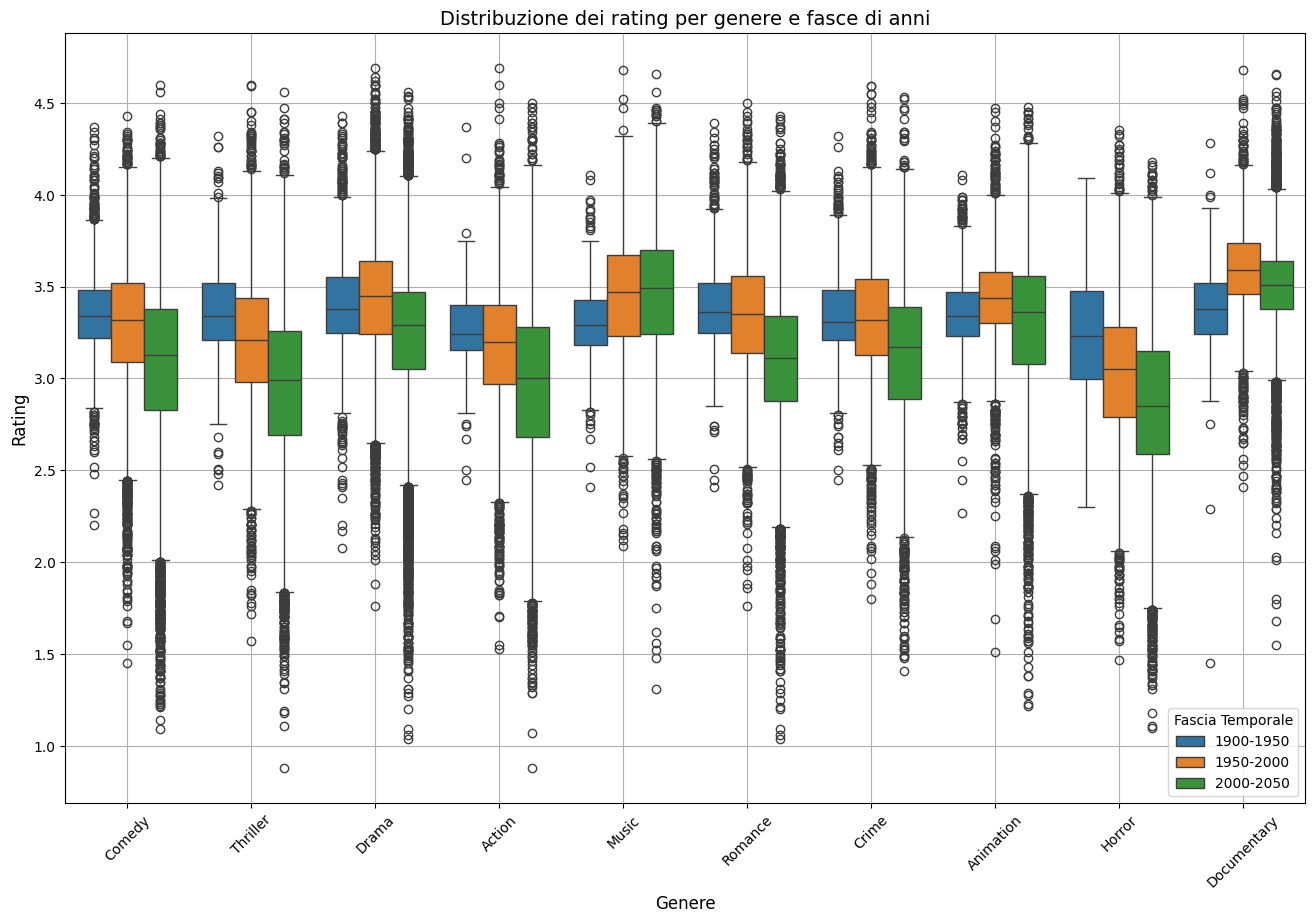

In [88]:
# Unire le tabelle movies e genres sulla colonna id_film
movies_genres = pd.merge(df_released_movies, df_genres, left_on="id", right_on="id_film", how="inner")

# Creare fasce temporali da 50 anni
bins = [1900, 1950, 2000, 2050]  
labels = ["1900-1950", "1950-2000", "2000-2050"]
movies_genres['year_range'] = pd.cut(movies_genres['date'], bins=bins, labels=labels, right=False)

top_genres = movies_genres["genre"].value_counts().nlargest(10).index
filtered_movies = movies_genres[movies_genres["genre"].isin(top_genres)]

plt.figure(figsize=(16, 10))
sns.boxplot(data=filtered_movies, x="genre", y="rating", hue="year_range")
plt.title("Distribuzione dei rating per genere e fasce di anni", fontsize=14)
plt.xlabel("Genere", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Fascia Temporale")
plt.grid(True)
plt.show()

Vediamo come chiaramente i documentari sono il genere che ha mantenuto una media delle valutazioni più alta durante gli anni, assieme alla musica.
Tutti i generi nella prima fascia temporale hanno una mediana simile (3.0 - 3.5) quindi possiamo dedurre che i cambiamenti sono avvenuti solo successivamente.
La musica è l'unico genere che ha avuto una continua crescita, mentre gli altri generi dopo una crescita iniziale hanno avuto un calo finale rispetto al loro inizio.
In ogni genere notiamo però come la presenza di outsider negativi sia aumentata nel tempo.
Capiamo quindi che vi è una correlazione tra il genere di un film e il suo rating.


Tornando al primo grafico sul numero di film pubblicati nel tempo,potremmo pensare che la causa di questo calo di valutazioni sia data dal continuo aumento nel numero di film che vengono prodotti.
Un numero ingente di film ogni anno porterebbe ad una possibile ripetitività nei film che di conseguenza annoierebbe lo spettatore medio.


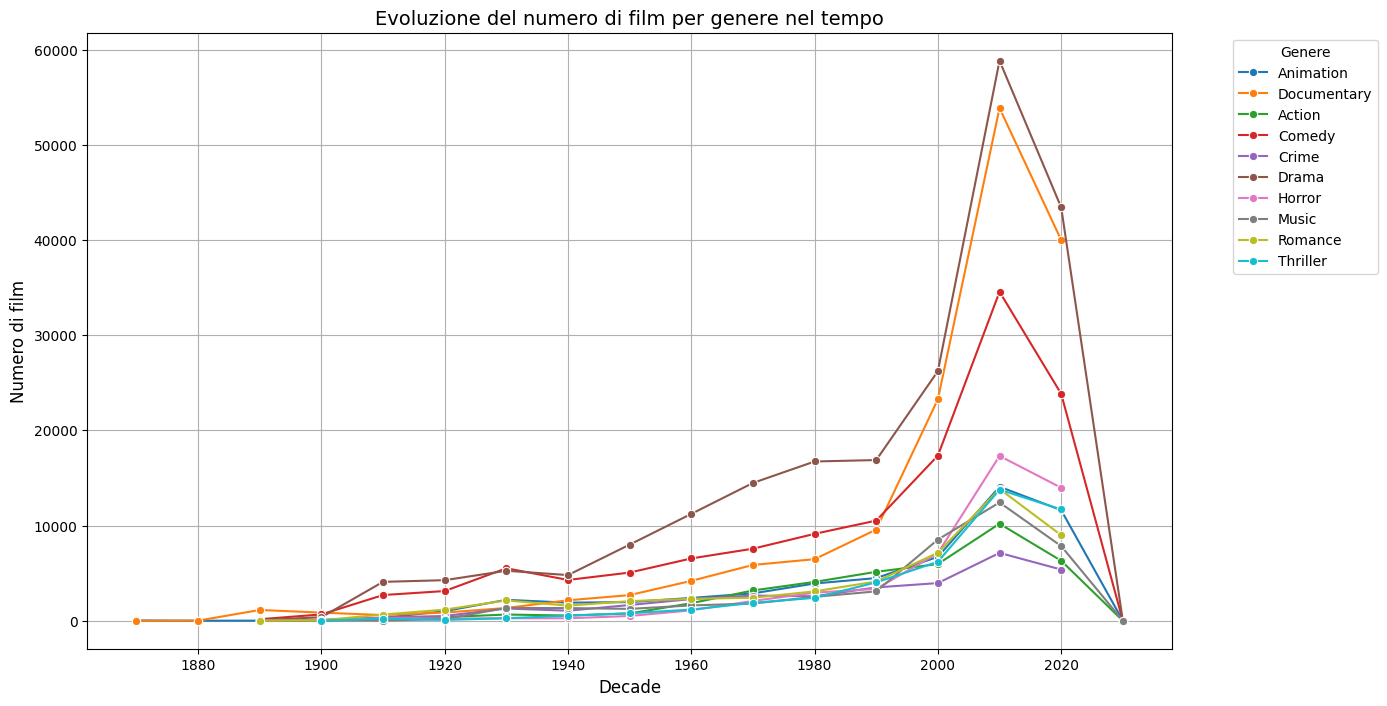

In [89]:
movies_genres['decade'] = (movies_genres['date'] // 10) * 10
genre_trend = movies_genres.groupby(['decade', 'genre']).size().reset_index(name='film_count')
#scegliamo i 10 generi più popolari
top_genres = movies_genres["genre"].value_counts().nlargest(10).index
filtered_trend = genre_trend[genre_trend['genre'].isin(top_genres)]

# Creare il grafico a linee
plt.figure(figsize=(14, 8))
sns.lineplot(data=filtered_trend, x="decade", y="film_count", hue="genre", marker="o")
plt.title("Evoluzione del numero di film per genere nel tempo", fontsize=14)
plt.xlabel("Decade", fontsize=12)
plt.ylabel("Numero di film", fontsize=12)
plt.legend(title="Genere", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

Vi è una crescita sostanziale tra il numero di film pubblicati, possiamo verificare se vi è una dipendenza con il rating per chiederci se producendo un numero maggiore di film la loro qualità diminuisca.


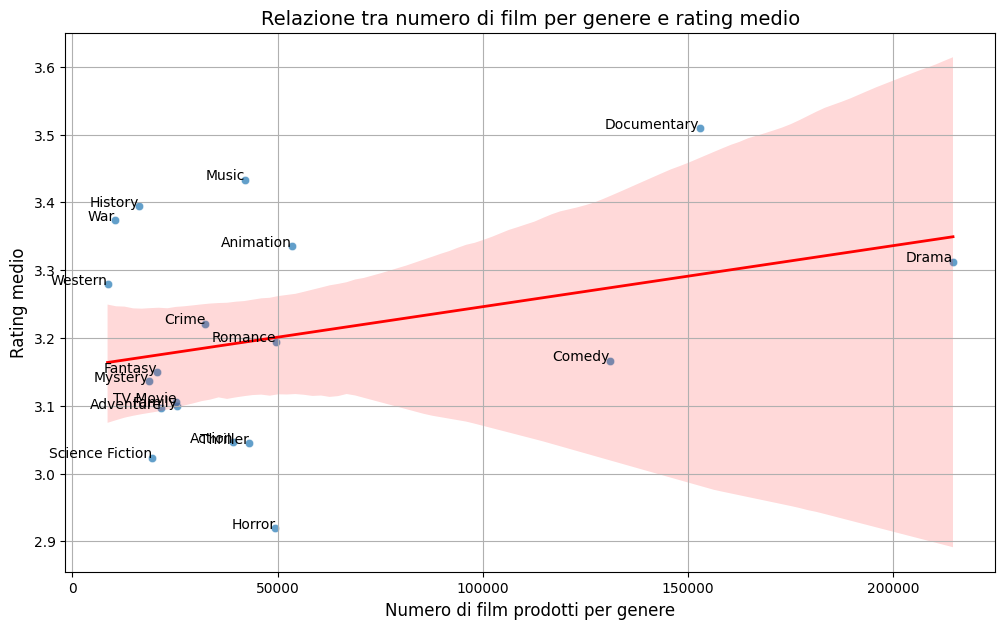

In [90]:
genre_stats = movies_genres.groupby("genre").agg(film_count=("id_film", "count"),avg_rating=("rating", "mean")).reset_index()
plt.figure(figsize=(12, 7))
sns.scatterplot(data=genre_stats, x="film_count", y="avg_rating", alpha=0.7)

# Aggiungiamo una linea di tendenza solo per rendere più leggibile il grafico
sns.regplot(data=genre_stats, x="film_count", y="avg_rating", scatter=False, color="red", line_kws={"linewidth": 2})
plt.title("Relazione tra numero di film per genere e rating medio", fontsize=14)
plt.xlabel("Numero di film prodotti per genere", fontsize=12)
plt.ylabel("Rating medio", fontsize=12)
plt.grid(True)

for i, row in genre_stats.iterrows():
    if row["film_count"] > 1000:
        plt.text(row["film_count"], row["avg_rating"], row["genre"], fontsize=10, ha='right')
plt.show()

Per rispondere alla nostra domanda precedente, notiamo che in realtà la correlazione è leggermente positiva (linea rossa in crescita), quindi anche se il numero di film di genere aumenta, la maggior parte dei rating medi tende a salire.
Per esempio il Drama è il genere più prolifico, perchè con un vasto numero di film prodotti mantiene un rating medio del 3.3 .
Notiamo che i Documentari hanno il rating medio più alto mentre gli Horror quello minore.
Quindi non vediamo un chiaro calo del rating, generi molto prodotti riescono a mantenere abbastanza un buon rating medio, mentre quelli meno prodotti hanno rating più alti ma con molta variabilità.


Resta però che anche se in piccola quantità, la quantità di film prodotti per genere impatta il voto medio, probabilmente a causa di una minore attenzione alla qualità dei film stessi.


Possiamo pensare però che sia la durata dei film stessi a incidere sul loro rating, quindi film più lunghi possono avere valutazioni peggiori o migliori.


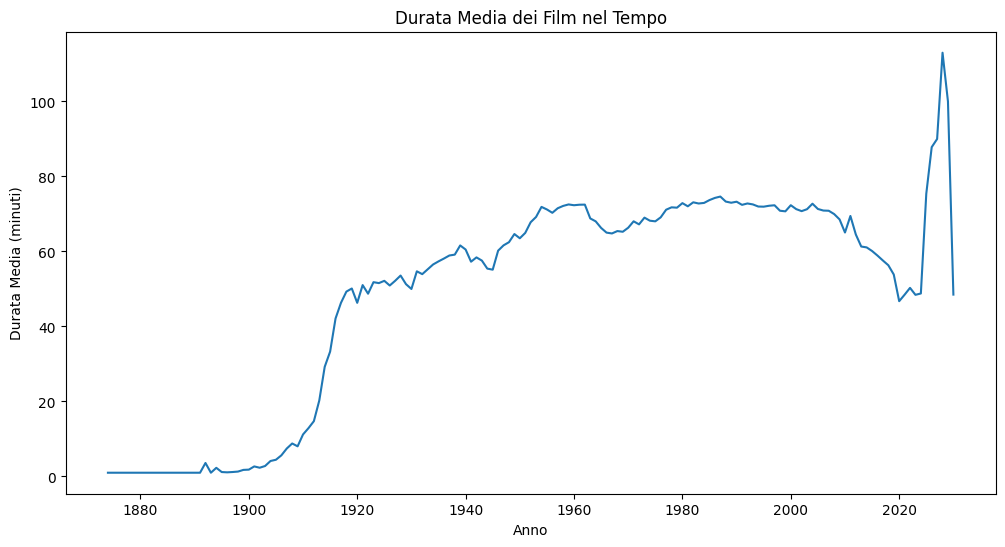

In [91]:
durata_media_anni = df_released_movies.groupby('date')['minute'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x=durata_media_anni['date'], y=durata_media_anni['minute'])
plt.title("Durata Media dei Film nel Tempo")
plt.xlabel("Anno")
plt.ylabel("Durata Media (minuti)")
plt.show()


La durata dei film in media dell'anno è aumentata, questo ci può far pensare che questo aumento sia la causa della diminuzione delle valutazioni.

Creiamo uno scatterplot per rappresentare la correlazione tra durata e rating.


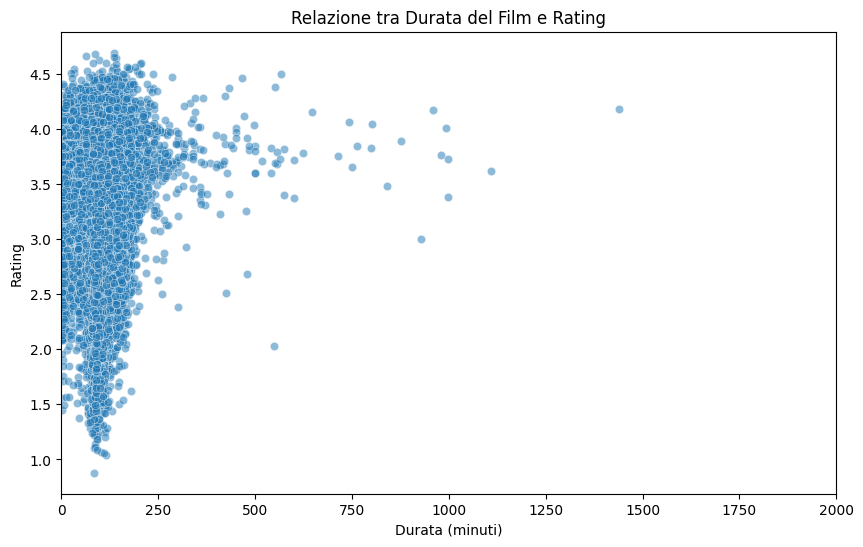

In [92]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_released_movies['minute'], y=df_released_movies['rating'], alpha=0.5)
plt.xlim(0, 2000)
plt.title("Relazione tra Durata del Film e Rating")
plt.xlabel("Durata (minuti)")
plt.ylabel("Rating")
plt.show()

In [93]:
correlation = df_released_movies[['minute', 'rating']].corr()
print("Correlazione tra durata e rating:")
print(correlation)

Correlazione tra durata e rating:
          minute    rating
minute  1.000000 -0.006635
rating -0.006635  1.000000


Vediamo che la correlazione non è presente, essendo il valore piu vicino 0 rispetto ad 1 o -1.
Quindi possiamo affermare che anche la durata dei film non sia una delle cause principali della diminuzione del rating.


### Risultato analisi:

Uno dei fattori più evidenti che abbiamo analizzato è che il numero di film prodotti è aumentato notevolmente nel tempo. Questo porta a diversi effetti:

Diminuzione della qualità media: Con l'aumento del numero di film, è più probabile che vengano prodotti molti film di qualità inferiore, riducendo il rating medio complessivo.
Sovraccarico del pubblico: Con troppi film disponibili, gli spettatori possono diventare più esigenti e difficilmente daranno buone valutazioni.
Produzione industrializzata: La crescente commercializzazione e standardizzazione di molti film può portare a sceneggiature meno originali,con storie ripetute molte volte,abbassando la percezione della qualità.

Sicuramente il cambiamento del gusto del pubblico,infatti possiamo notare che ci sono generi che hanno un valore molto maggiore in alcune fasce annuali, come il Drama negli anni del dopoguerra e i generi Music negli anni più recenti.
Infine quasi sicuramente l'accessibilità alle recensioni è aumentata, causando quindi il voto del pubblico di essere maggiore con il tempo con l'avvento delle critiche online.


---


## Analisi degli Oscar dei paesi produttori di film

- Vi sono paesi che hanno prodotto più film di alto successo ? Se si, di conseguenza quei paesi avranno vinto più Oscar con film prodotti dal loro?
- Ci sono paesi che soltanto recentemente, oltre l'anno 2000, hanno iniziato a vincere premi ?
- È presente un genere di film che si discosta particolarmente rispetto agli altri per il numero di Oscar vinti?


In [94]:
df_successfull_movies= df_movies[df_movies["rating"]>=4]
successful_movies_countries= df_successfull_movies.merge(df_countries,left_on="id",right_on="id_film", how="left")
successful_movies_per_country = (
    successful_movies_countries.groupby('country')['id'].count().reset_index().rename(columns={'id': 'successful_movies_count'})
)
successful_movies_per_country = successful_movies_per_country.sort_values(
    by='successful_movies_count', ascending=False
)
print("Top 10 Paesi con il maggior numero di film di successo:\n ",  successful_movies_per_country.head(10))

Top 10 Paesi con il maggior numero di film di successo:
          country  successful_movies_count
85          USA                      941
84           UK                      333
40        Japan                      309
25       France                      287
27      Germany                      120
39        Italy                      105
74  South Korea                       93
77       Sweden                       44
75        Spain                       37
86         USSR                       35


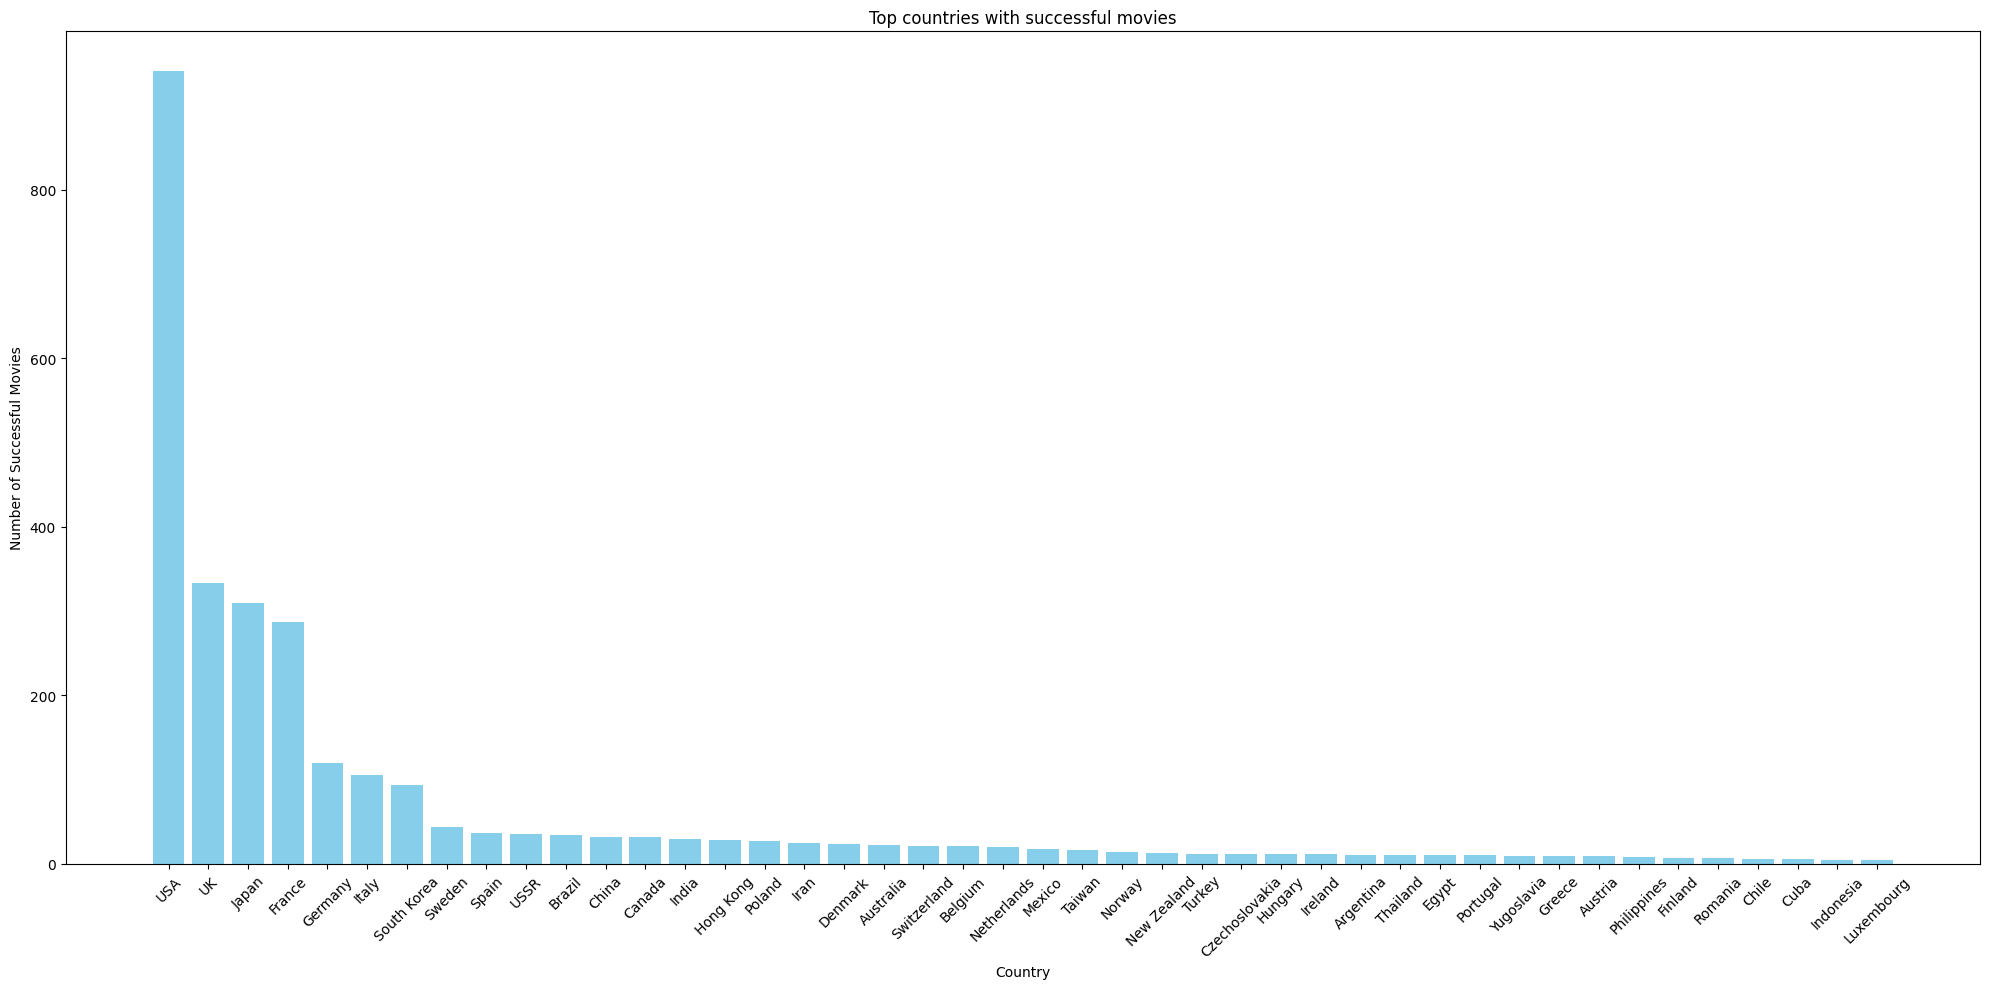

In [95]:
#abbiamo deciso di considerare solo i paesi che hanno almeno 5 film di successo, in modo da avere un campione più significativo
min_successful_movies = 5 
filtered_countries = successful_movies_per_country[
    successful_movies_per_country['successful_movies_count'] >= min_successful_movies
]
plt.figure(figsize=(20, 10))
plt.bar(filtered_countries['country'], filtered_countries['successful_movies_count'], color='skyblue')
plt.xlabel('Country')
plt.ylabel('Number of Successful Movies')
plt.title('Top countries with successful movies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Notiamo quindi che gli Stati Uniti sono il paese con il maggior numero di film di successo, seguito da Regno Unito e Francia.
Possiamo aspettarci quindi che grafico degli oscar vinti per paese possa rispecchiare questo risultato, avendo l'America un numero maggiore di film di successo.
Calcoliamo quanti oscar sono stati vinti dai paesi produttori di film.


In [96]:
df_oscars["year_film"] = pd.to_numeric(df_oscars["year_film"], errors="coerce").astype("Int64")
df_oscars["year_ceremony"] = pd.to_numeric(df_oscars["year_ceremony"], errors="coerce").astype("Int64")

In [97]:

oscars_winners = df_oscars[df_oscars["winner"] == True]
oscars_winners = oscars_winners.merge(df_movies, left_on="film", right_on="name", how="left")
oscars_winners = oscars_winners.merge(df_countries,left_on="id", right_on="id_film", how="left")
oscar_per_country = oscars_winners.groupby("country").size().reset_index(name="oscar_count")
oscar_per_country = oscar_per_country.sort_values(by="oscar_count", ascending=False)
print(oscar_per_country.head(10))

        country  oscar_count
98          USA         3608
97           UK          937
32       France          407
34      Germany          281
16       Canada          231
41        India          194
49        Japan          192
47        Italy          176
88  South Korea          120
89        Spain          116


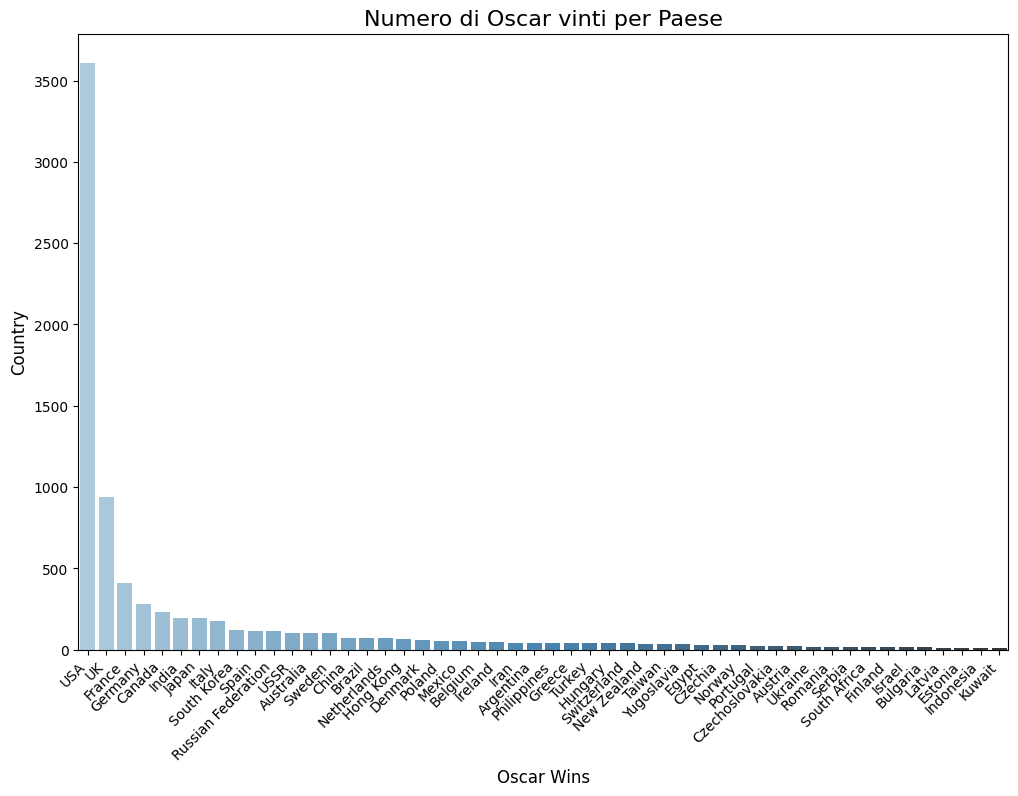

In [98]:
#aumentiamo il numero di oscar per paese in modo che la visualizzazione venga piu chiara
oscar_per_country = oscar_per_country[oscar_per_country["oscar_count"]>10]
plt.figure(figsize=(12, 8))
sns.barplot(x='country', y='oscar_count', data=oscar_per_country, palette='Blues_d',hue='country')
plt.title('Numero di Oscar vinti per Paese' , fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Oscar Wins', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.show()

In [99]:
fig = px.choropleth(
    oscar_per_country.reset_index(), 
    locations='country', 
    locationmode='country names', 
    color='oscar_count',
    title="Paesi che hanno vinto più Oscar",
    color_continuous_scale='Viridis'
)
fig.show()

Vediamo chiaramente come l'America abbia un controllo sul numero di Oscar vinti, questo probabilmente dovuto alla supremazia di Hollywood come casa produttrice.
La situazione non cambia nelle prime 3 posizioni, mentre successivamente notiamo che i paesi con più film con oscar vinti variano rispetto ai paesi con film di maggior successo, identificando come questo non sia strettamente legato ai film di successo ma più alla quantità di film prodotti, quindi possiamo dedurre che con più film si hanno più possibilità di ottenere una nominazione qualsiasi agli Oscar.


Possiamo vedere se vi sono paesi che soltanto recentemente(successivamente all'anno 1990) hanno iniziato a vincere Oscar.


In [100]:
before_1990 = oscars_winners[oscars_winners['year_ceremony'] < 1990]
after_1990 = oscars_winners[oscars_winners['year_ceremony'] >= 1990]

before_1990_counts = before_1990['country'].value_counts()
after_1990_counts = after_1990['country'].value_counts()

oscar_counts_BothSides = pd.DataFrame({'Oscars_before_1990': before_1990_counts, 'Oscars_after_1990': after_1990_counts}).fillna(0)
popular_after_1990 = oscar_counts_BothSides[(oscar_counts_BothSides['Oscars_before_1990'] < 5) & (oscar_counts_BothSides['Oscars_after_1990'] >= 5)]
print(popular_after_1990)

Empty DataFrame
Columns: [Oscars_before_1990, Oscars_after_1990]
Index: []


In [101]:
# Creiamo una colonna per evidenziare i paesi che soddisfano il criterio
oscar_counts_BothSides['highlight'] = oscar_counts_BothSides.index.isin(popular_after_1990.index)
fig_before = px.bar(oscar_counts_BothSides,
                    x=oscar_counts_BothSides.index,
                    y='Oscars_before_1990',
                    labels={'x': 'Paese', 'y': 'Numero di Oscar'},
                    title='Premi Oscar vinti prima del 1990',
                    color='highlight',
                    color_discrete_map={True: 'red', False: 'lightblue'})
fig_after = px.bar(oscar_counts_BothSides,
                   x=oscar_counts_BothSides.index,
                   y='Oscars_after_1990',
                   labels={'x': 'Paese', 'y': 'Numero di Oscar'},
                   title='Premi Oscar vinti dopo il 1990',
                   color='highlight',
                   color_discrete_map={True: 'red', False: 'lightgreen'})
#riduciamo il range dell'asse y per rendere i grafici più leggibili 
fig_before.update_layout(
    yaxis=dict(range=[0, 50])
)
fig_after.update_layout(
    yaxis=dict(range=[0, 50])
)
fig_before.show()
fig_after.show()

Si discostano Thailandia, Kuwait, Indonesia, Islanda, Georgia, Estonia, Chile e Croazia, quindi potremmo ipotizzare il loro sviluppo nella produzione cinematografica.


Analiziamo i generi premiati di più nella storia cinematografica,vedendo principalmente la loro dispersione all'interno del paese principale con il maggior numero di premi posseduti, quindi l'America.


In [102]:
oscars_winners_with_genres = oscars_winners.merge(df_genres, left_on="id", right_on="id_film", how="left")
oscar_per_genre = oscars_winners_with_genres.groupby('genre').size().reset_index(name='oscar_count')
oscar_per_genre = oscar_per_genre.sort_values(by='oscar_count', ascending=False)
print("Top 10 Genres with the most Oscars:\n", oscar_per_genre.head(10))

Top 10 Genres with the most Oscars:
           genre  oscar_count
6         Drama         4899
13      Romance         1466
3        Comedy         1274
2     Animation         1074
5   Documentary         1003
9       History          745
1     Adventure          665
16     Thriller          652
0        Action          588
8       Fantasy          549


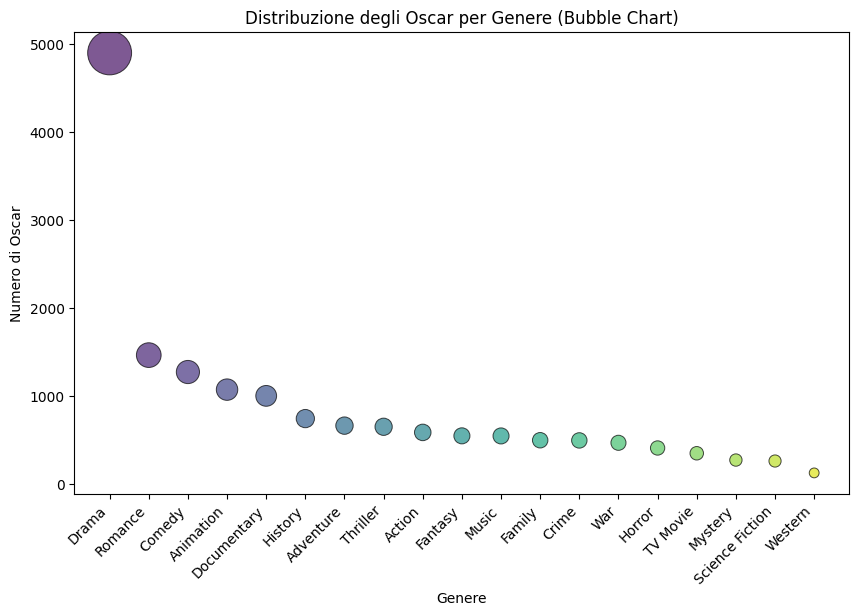

In [103]:
plt.figure(figsize=(10, 6))
scatter=sns.scatterplot(
    x=range(len(oscar_per_genre)), 
    y=oscar_per_genre["oscar_count"], 
    size=oscar_per_genre["oscar_count"], 
    sizes=(50, 1000),  # Regola la dimensione delle bolle
    hue=oscar_per_genre["genre"], 
    palette="viridis", 
    edgecolor="black", 
    alpha=0.7,
    legend=False
)
plt.xticks(range(len(oscar_per_genre)), oscar_per_genre["genre"], rotation=45, ha="right")
plt.xlabel("Genere")
plt.ylabel("Numero di Oscar")
plt.title("Distribuzione degli Oscar per Genere (Bubble Chart)")
plt.show()

Considerando che il genere drammatico è il vincitore di più Oscar rispetto a tutti gli altri generi possiamo vedere se effettivamente questo dato viene ripreso negli Oscar vinti in America.


Empty DataFrame
Columns: []
Index: []


ValueError: zero-size array to reduction operation fmin which has no identity

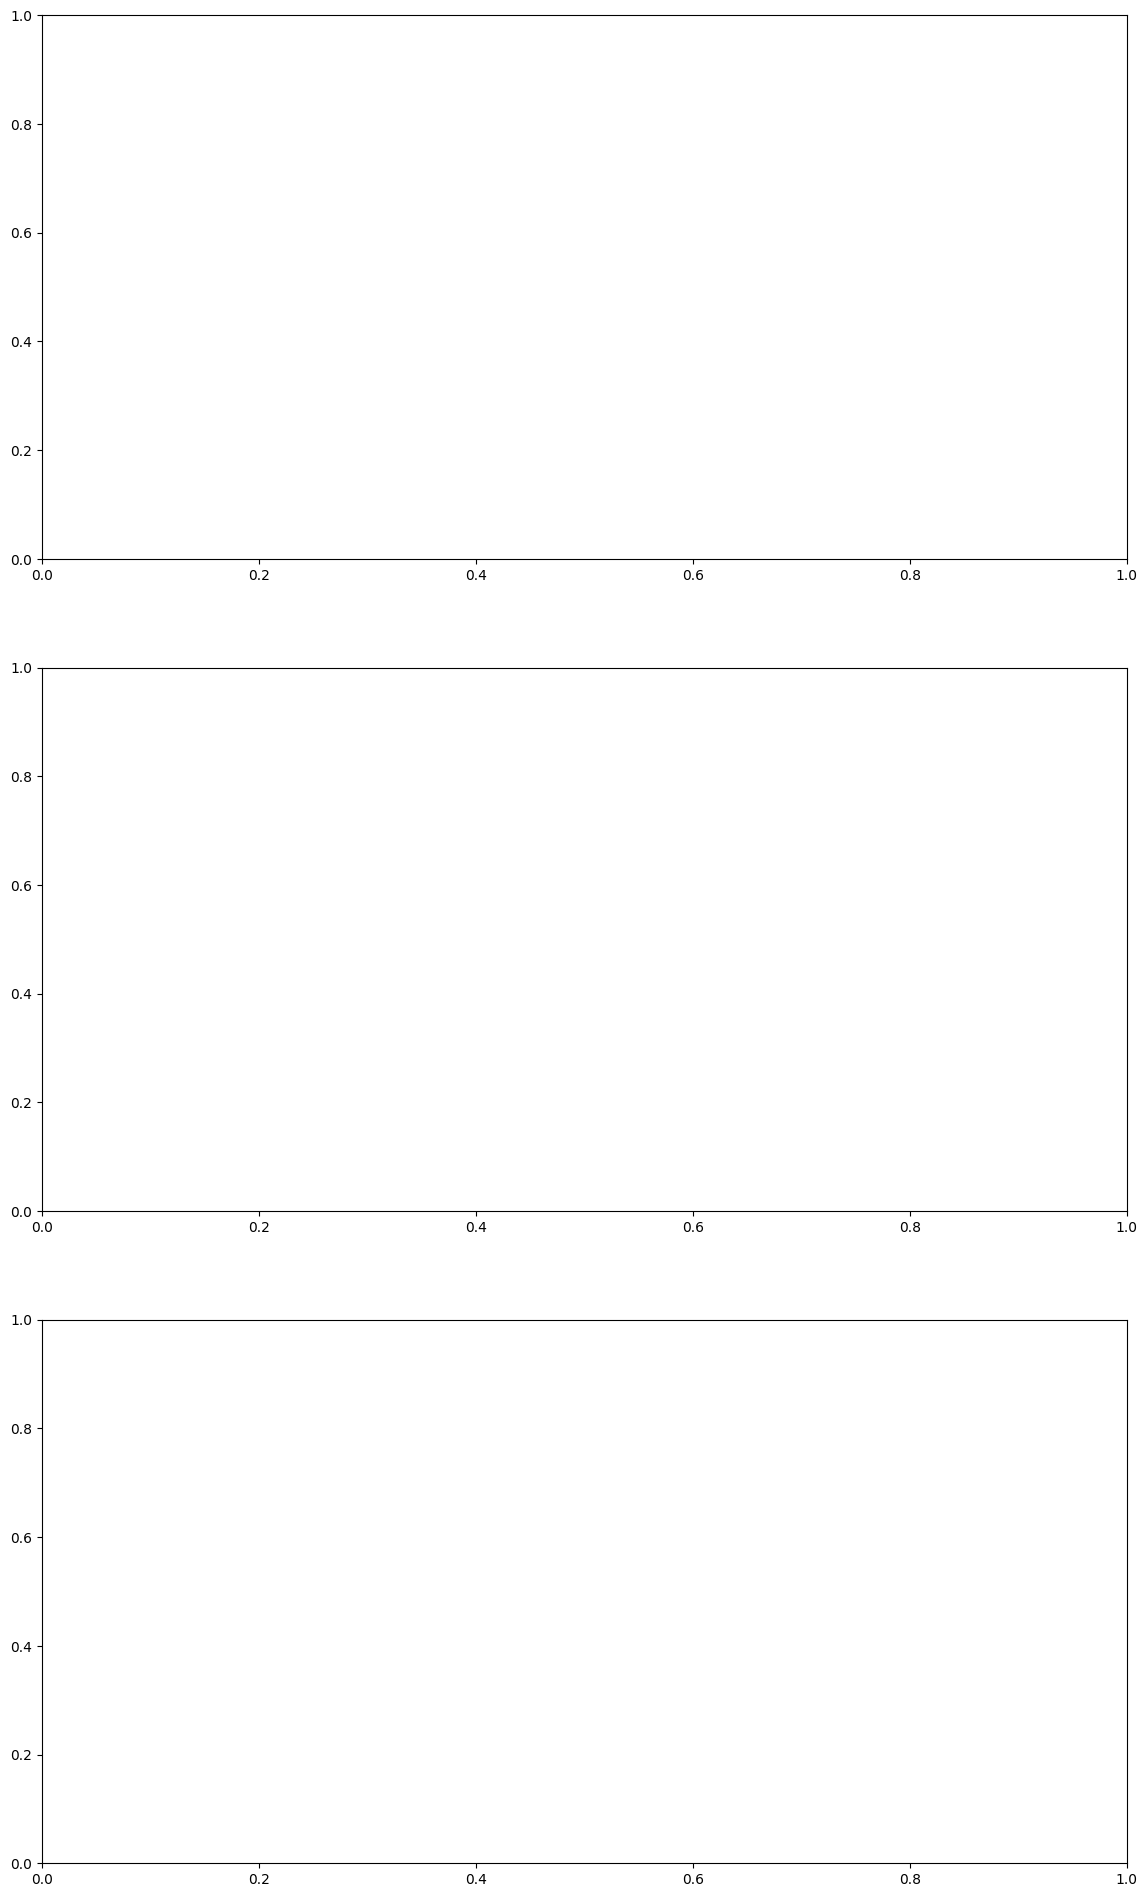

In [104]:
oscars_usa_with_genres = oscars_winners[oscars_winners['country'] == 'USA'].merge(df_genres, left_on="id", right_on="id_film", how="left")
oscar_per_genre_year = oscars_usa_with_genres.groupby(['year_ceremony', 'genre']).size().reset_index(name='oscar_count')
oscar_per_genre_year['year_ceremony'] = pd.to_datetime(oscar_per_genre_year['year_ceremony'],errors='coerce',format='%Y')
pivot_table = oscar_per_genre_year.pivot(index='year_ceremony', columns='genre', values='oscar_count').fillna(0)
periods = [(1900, 1950), (1951, 2000), (2001, 2050)]  # Periodi 50 anni
fig, axes = plt.subplots(len(periods), 1, figsize=(14, 8 * len(periods)))
print(pivot_table)
#in modo da creare una heatmap per ogni periodo
for i, (start_year, end_year) in enumerate(periods):
    period_data = pivot_table[(pivot_table.index.year >= start_year) & (pivot_table.index.year <= end_year)]
    
    sns.heatmap(period_data.T, cmap='Blues', linewidths=0.5, linecolor='gray', annot=False, ax=axes[i])
    axes[i].set_xticks(range(len(period_data.index)))  # Imposta i tick sugli indici numerici
    axes[i].set_xticklabels(period_data.index.year)
    axes[i].set_title(f'Fluttuazioni dei Generi Oscar vinti dagli USA ({start_year}-{end_year})', fontsize=16)
    axes[i].set_xlabel('Anno della Cerimonia')
    axes[i].set_ylabel('Genere')
    
plt.tight_layout()
plt.show()


Notiamo chiaramente che il genere Drammatico resta sempre il genere più premiato nel corso degli anni in America.


### Risultato della analisi:

Possiamo affermare che l'America è il paese che ha prodotto film di maggiore successo all'interno nella storia, vincendo anche la maggior parte degli Oscar nei film prodotti nel paese.

Abbiamo anche notato che Thailandia, Kuwait, Indonesia, Islanda, Georgia, Estonia, Chile e Croazia soltanto recentemente hanno iniziato a vincere piu premi rispetto al loro passato dove non ne avevano oppure ne avevano molti pochi.

I film che hanno vinto più premi in America sono quelli con alla loro base il genere Drammatico.


######

vietati in quale stato (raggruppare i rating di PG vietato ai minori)

quante uscite per ogni anno(anche in base a quanti "caratteristica varia: ")

film vietati ai minori

istogramma di frequenze

notare che i rating della critica sono diversi da quelli degli utenti (quindi magari aggiungere qualcosa anche sopra )

dare uno scopo alla propria analisi (molto intelligente fare 2 analisi diverse)
dove si dà un senso alla analisi che si fà tipo " Notare che l'africa ha un sacco di oscar"


## Come i temi dei film sono cambiati nel tempo

- Alcuni temi sono più presenti in certi paesi rispetto ad altri?
- I film storici sono più frequenti in Europa? I film d’azione dominano negli USA?
- I film di fantascienza sono aumentati in Asia negli ultimi decenni?


Partiremo con una analisi di quali temi sono stati i prevalenti durante i vari anni


In [105]:
df_themes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125641 entries, 0 to 125640
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   id_film  125641 non-null  int64 
 1   theme    125641 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.9+ MB


In [106]:
df_released_cl_data = df_movies.dropna(subset=["date"])[["id", "date", "rating", "name"]]
df_released_cl_data = df_released_cl_data.dropna(subset=["rating", "date"])
df_released_cl_data["date"] = df_released_cl_data["date"].astype(int)
df_released_cl_data = df_released_cl_data[(1910<df_released_cl_data["date"])&(df_released_cl_data["date"]<2020)]

{'whiskers': [<matplotlib.lines.Line2D at 0x16e051d30>,
 'caps': [<matplotlib.lines.Line2D at 0x16e050950>,
 'boxes': [<matplotlib.lines.Line2D at 0x3550e92b0>],
 'medians': [<matplotlib.lines.Line2D at 0x16e051280>],
 'fliers': [<matplotlib.lines.Line2D at 0x16e0c81d0>],
 'means': []}

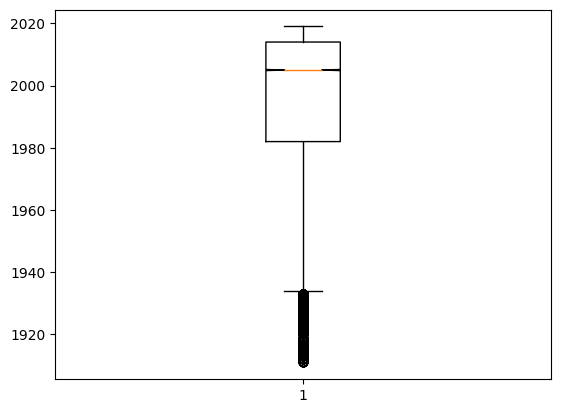

In [107]:
plt.boxplot(df_released_cl_data["date"], df_released_cl_data.groupby("date")["rating"].count().tolist())

In [108]:
data_film_count = df_released_cl_data.groupby("date")["rating"].count()

(array([  21.,   40.,   36.,   59.,   38.,   45.,   35.,   39.,   54.,
          47.,   62.,   55.,   38.,   49.,   63.,   61.,   75.,  103.,
         136.,  129.,  168.,  202.,  212.,  223.,  203.,  213.,  196.,
         188.,  195.,  188.,  200.,  212.,  211.,  196.,  192.,  200.,
         224.,  234.,  255.,  247.,  249.,  249.,  260.,  268.,  292.,
         295.,  307.,  320.,  301.,  291.,  296.,  338.,  344.,  394.,
         406.,  470.,  461.,  513.,  492.,  509.,  533.,  592.,  553.,
         530.,  506.,  535.,  526.,  506.,  551.,  541.,  548.,  592.,
         594.,  589.,  598.,  676.,  743.,  762.,  761.,  677.,  682.,
         702.,  705.,  722.,  784.,  758.,  807.,  855.,  918.,  986.,
        1045., 1084., 1120., 1274., 1383., 1548., 1647., 1684., 1850.,
        1882., 2085., 2280., 2489., 2753., 2911., 3232., 3659., 3790.,
        4119.]),
 array([1911.        , 1911.99082569, 1912.98165138, 1913.97247706,
        1914.96330275, 1915.95412844, 1916.94495413, 1917.93577

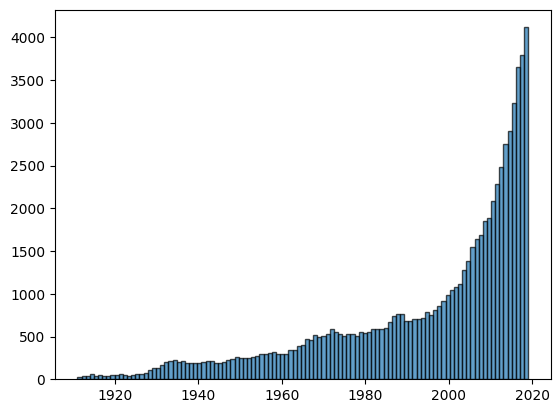

In [109]:
plt.hist(data_film_count.index, weights=data_film_count.values, bins=data_film_count.shape[0], edgecolor="black", alpha=0.7)

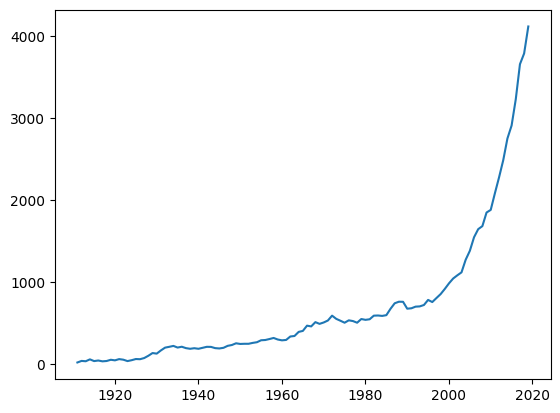

In [110]:
plt.plot(data_film_count)

In [111]:
df_themes.columns, df_released_cl_data.columns

(Index(['id_film', 'theme'], dtype='object'),
 Index(['id', 'date', 'rating', 'name'], dtype='object'))

[2010 1990 2000 1980 1970 1960 1950 1940 1930 1920 1910]


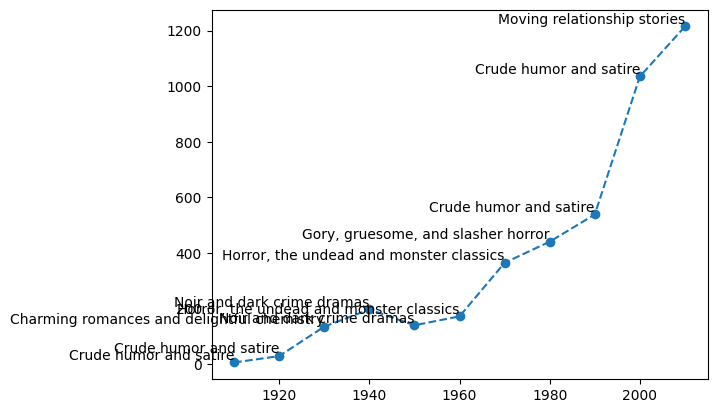

In [112]:
merged_themes = df_themes.merge(df_released_cl_data, how="inner", left_on="id_film", right_on="id")
merged_themes["date_bin"] = (merged_themes["date"] // 10) * 10 
print(merged_themes["date_bin"].unique())
df_date_theme = merged_themes[["date_bin", "theme"]].groupby("date_bin").value_counts().to_frame()
idx = df_date_theme.groupby(level=0)["count"].idxmax()
df_date_hot_theme = df_date_theme.loc[idx].reset_index()
plt.plot(df_date_hot_theme["date_bin"], df_date_hot_theme["count"], 'o--')
for i, txt in enumerate(df_date_hot_theme["theme"]):
    plt.text(df_date_hot_theme["date_bin"].iloc[i], df_date_hot_theme["count"].iloc[i], txt, fontsize=10, ha="right", va="bottom")

In [113]:
df_genres.columns

Index(['id_film', 'genre'], dtype='object')

[2010 1990 2000 1980 1970 1960 1950 1940 1930 1920 1910]


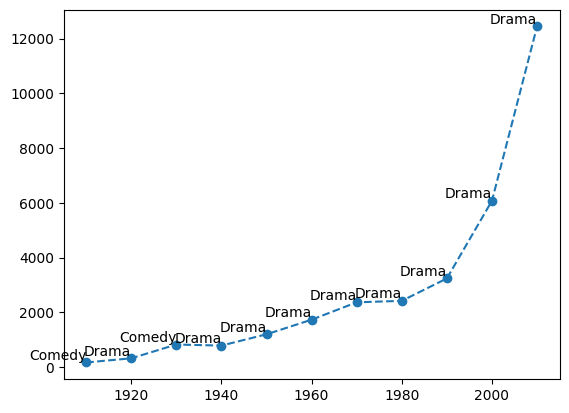

In [114]:
merged_genre = df_genres.merge(df_released_cl_data, how="inner", left_on="id_film", right_on="id")
merged_genre["date_bin"] = (merged_genre["date"] // 10) * 10
print(merged_genre["date_bin"].unique())
df_date_genre = merged_genre[["date_bin", "genre"]].groupby("date_bin").value_counts().to_frame()
idx = df_date_genre.groupby(level=0)["count"].idxmax()
df_date_hot_genre = df_date_genre.loc[idx].reset_index()
plt.plot(df_date_hot_genre["date_bin"], df_date_hot_genre["count"], 'o--')
for i, txt in enumerate(df_date_hot_genre["genre"]):
    plt.text(df_date_hot_genre["date_bin"].iloc[i], df_date_hot_genre["count"].iloc[i], txt, fontsize=10, ha="right", va="bottom")


In [115]:
genre_rating = merged_genre[["date_bin", "genre", "rating"]].groupby(["date_bin", "genre"]).agg(['mean', 'count'])["rating"].reset_index()
rating_per_year = merged_genre[["date_bin", "rating"]].groupby(["date_bin"]).count().reset_index().set_index("date_bin")

In [116]:
rating_per_year_dict = rating_per_year.to_dict()
rating_per_year_dict

{'rating': {1910: 596,
  1920: 1243,
  1930: 3938,
  1940: 4576,
  1950: 5633,
  1960: 7804,
  1970: 10878,
  1980: 13738,
  1990: 16802,
  2000: 29552,
  2010: 56717}}

In [117]:
genre_rating["mean_count"] = genre_rating["mean"] * genre_rating["count"]
genre_rating

,date_bin,genre,mean,count,mean_count
0,1910,Action,3.427083,24,82.25
1,1910,Adventure,3.279412,17,55.75
2,1910,Animation,3.429444,18,61.73
3,1910,Comedy,3.221404,171,550.86
4,1910,Crime,3.447576,33,113.77
...,...,...,...,...,...
200,2010,Science Fiction,3.001106,1645,4936.82
201,2010,TV Movie,3.000327,1225,3675.40
202,2010,Thriller,2.952587,4152,12259.14
203,2010,War,3.249585,458,1488.31


In [118]:
genre_rating["w_avg"] = genre_rating.apply(lambda x: x["mean_count"]/rating_per_year["rating"][x["date_bin"]], axis=1)
genre_rating

,date_bin,genre,mean,count,mean_count,w_avg
0,1910,Action,3.427083,24,82.25,0.138003
1,1910,Adventure,3.279412,17,55.75,0.093540
2,1910,Animation,3.429444,18,61.73,0.103574
3,1910,Comedy,3.221404,171,550.86,0.924262
4,1910,Crime,3.447576,33,113.77,0.190889
...,...,...,...,...,...,...
200,2010,Science Fiction,3.001106,1645,4936.82,0.087043
201,2010,TV Movie,3.000327,1225,3675.40,0.064802
202,2010,Thriller,2.952587,4152,12259.14,0.216146
203,2010,War,3.249585,458,1488.31,0.026241


In [119]:
df_highest_genre = genre_rating.loc[genre_rating.groupby("date_bin")["w_avg"].idxmax()].reset_index(drop=True)
df_highest_genre

,date_bin,genre,mean,count,mean_count,w_avg
0,1910,Comedy,3.221404,171,550.86,0.924262
1,1920,Drama,3.464644,323,1119.08,0.900306
2,1930,Comedy,3.357485,827,2776.64,0.705089
3,1940,Drama,3.438287,788,2709.37,0.592083
4,1950,Drama,3.476117,1200,4171.34,0.740518
5,1960,Drama,3.526995,1734,6115.81,0.783676
6,1970,Drama,3.454901,2369,8184.66,0.752405
7,1980,Drama,3.437560,2422,8325.77,0.606039
8,1990,Drama,3.396430,3241,11007.83,0.655150
9,2000,Drama,3.310197,6079,20122.69,0.680925


In [120]:
'''
idx = genre_rating[["date_bin", "genre"]].groupby("date_bin").idxmax()
df_date_best_genre = genre_rating[["date_bin", "genre", "w_avg"]].loc[idx]
plt.plot(df_date_best_genre["date_bin"], df_date_best_genre["rating"], 'o--')
for i, txt in enumerate(df_date_best_genre["genre"]):
    plt.text(df_date_best_genre["date_bin"].iloc[i], df_date_best_genre["rating"].iloc[i], txt, fontsize=10, ha="right", va="bottom")
'''

'\nidx = genre_rating[["date_bin", "genre"]].groupby("date_bin").idxmax()\ndf_date_best_genre = genre_rating[["date_bin", "genre", "w_avg"]].loc[idx]\nplt.plot(df_date_best_genre["date_bin"], df_date_best_genre["rating"], \'o--\')\nfor i, txt in enumerate(df_date_best_genre["genre"]):\n    plt.text(df_date_best_genre["date_bin"].iloc[i], df_date_best_genre["rating"].iloc[i], txt, fontsize=10, ha="right", va="bottom")\n'

In [121]:
genre_rating_dropped = merged_genre[["date_bin", "genre", "rating"]].groupby(["date_bin", "genre"]).mean().dropna(subset=["rating"])

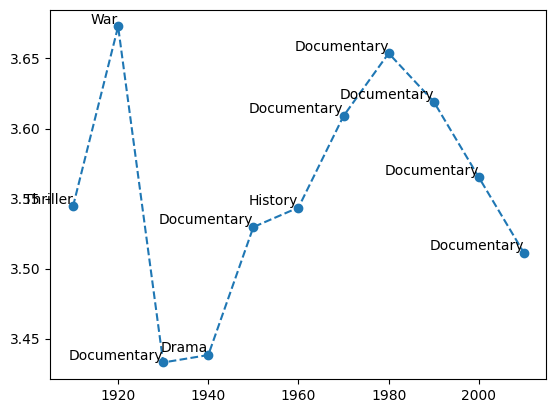

In [122]:
idx = genre_rating_dropped.groupby(level=0)["rating"].idxmax()
df_date_best_genre = genre_rating_dropped.loc[idx].reset_index()
plt.plot(df_date_best_genre["date_bin"], df_date_best_genre["rating"], 'o--')
for i, txt in enumerate(df_date_best_genre["genre"]):
    plt.text(df_date_best_genre["date_bin"].iloc[i], df_date_best_genre["rating"].iloc[i], txt, fontsize=10, ha="right", va="bottom")

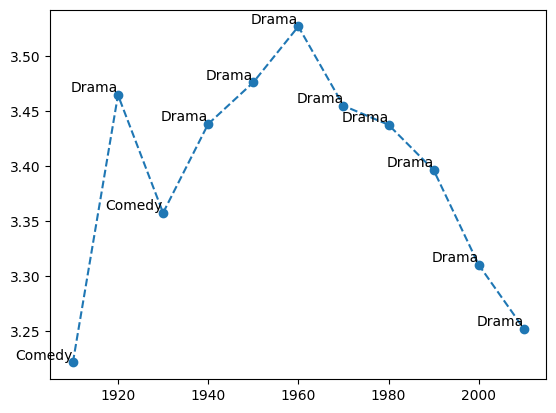

In [123]:
plt.plot(df_highest_genre["date_bin"], df_highest_genre["mean"], 'o--')
for i, txt in enumerate(df_highest_genre["genre"]):
    plt.text(df_highest_genre["date_bin"].iloc[i], df_highest_genre["mean"].iloc[i], txt, fontsize=10, ha="right", va="bottom")

In [124]:
df_filtered_movies = df_movies.dropna(subset=["date", "rating", "name"])[["id", "name", "rating", "date"]]
df_filtered_movies["date"] = df_filtered_movies["date"].astype("int")
df_filtered_movies = df_filtered_movies[(df_filtered_movies["date"] < 2020)&(df_filtered_movies["date"] > 1915)]
df_filtered_movies.dtypes

id          int64
name       object
rating    float64
date        int64
dtype: object

## Hollywood????


In [125]:

hollywood_studios = ["warner", "paramount", "sony", "universal", "warner", "20thcenturyfox"]
pattern = '|'.join(hollywood_studios)

In [126]:
df_hw_studios = df_studios[df_studios["studio"].apply(lambda x: x.lower().replace(" ", "")).str.contains(pattern, na=False, regex=True)].set_index("id_film")

In [127]:
#df_movies[df_movies.set_index('id').loc[df_hw_studios.index]]
df_hw_movies = df_filtered_movies[df_filtered_movies.set_index('id').index.isin(df_hw_studios.index)]
df_not_hw_movies = df_filtered_movies[~df_filtered_movies.set_index('id').index.isin(df_hw_studios.index)]
df_hw_movies.shape, df_not_hw_movies.shape

((6509, 4), (67363, 4))

In [128]:
df_rating_plot_hw = df_hw_movies.groupby("date").mean("rating")
df_rating_plot_not_hw = df_not_hw_movies.groupby("date").mean("rating")
df_rating_plot_not_hw

,id,rating
date,,
1916,1.045599e+06,3.403000
1917,1.047470e+06,3.307333
1918,1.048918e+06,3.290286
1919,1.045675e+06,3.391042
1920,1.038427e+06,3.406889
...,...,...
2015,1.055140e+06,3.178761
2016,1.055560e+06,3.180123
2017,1.055212e+06,3.184691


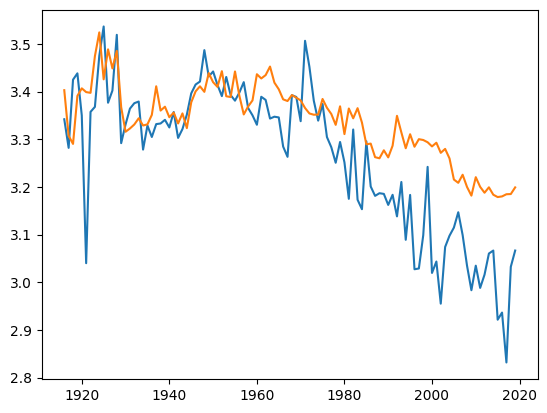

In [129]:
plt.plot(df_rating_plot_hw.index, df_rating_plot_hw["rating"])
plt.plot(df_rating_plot_not_hw.index, df_rating_plot_not_hw["rating"])
# violin e/o barplot con punte collegate per vedere il periodo di massimo splendore dei film di hollywood e non di hollywood

## Continuazione


Avendo ora una idea del comportamento dei temi durante gli anni, possiamo ora analizzarne i comportamenti geograficamente.


In [130]:
releases = df_releases.merge(df_countries, left_on="id_film", right_on="id_film", how="left")
releases

,id_film,country_x,date,type,age_min,country_y
0,1000001,Andorra,2023-07-21,Theatrical,NaN,UK
1,1000001,Andorra,2023-07-21,Theatrical,NaN,USA
2,1000001,Argentina,2023-07-20,Theatrical,NaN,UK
3,1000001,Argentina,2023-07-20,Theatrical,NaN,USA
4,1000001,Australia,2023-07-19,Theatrical,10.0,UK
...,...,...,...,...,...,...
1660277,1940967,USA,1909-01-01,Theatrical,NaN,USA
1660278,1940968,Sweden,1908-11-11,Theatrical,NaN,Sweden
1660279,1940969,France,1902-01-01,Theatrical,NaN,France
1660280,1940970,France,1902-01-01,Theatrical,NaN,France


In [131]:
themes_geo = releases.merge(df_themes, on="id_film", how="inner")[["country_y", "theme"]]
themes_geo.columns = ["Country", "Theme"]

In [132]:
theme_counts = themes_geo.groupby(["Country", "Theme"]).size().reset_index(name="Count")
total_movies_per_country = theme_counts.groupby("Country")["Count"].sum().reset_index()
total_movies_per_country.columns = ["Country", "Total_Movies"]
theme_counts = theme_counts.merge(total_movies_per_country, on="Country")

theme_counts["Percentage"] = (theme_counts["Count"] / theme_counts["Total_Movies"]) * 100
theme_counts

,Country,Theme,Count,Total_Movies,Percentage
0,Afghanistan,Disastrous voyages and heroic survival,3,65,4.615385
1,Afghanistan,Emotional and touching family dramas,7,65,10.769231
2,Afghanistan,Epic adventure and breathtaking battles,3,65,4.615385
3,Afghanistan,Heartbreaking and moving family drama,7,65,10.769231
4,Afghanistan,Historical battles and epic heroism,1,65,1.538462
...,...,...,...,...,...
5898,Zambia,Thought-provoking sci-fi action and future tec...,1,2,50.000000
5899,Zimbabwe,"Gripping, intense violent crime",30,120,25.000000
5900,Zimbabwe,Heartbreaking and moving family drama,30,120,25.000000
5901,Zimbabwe,Politics and human rights,30,120,25.000000


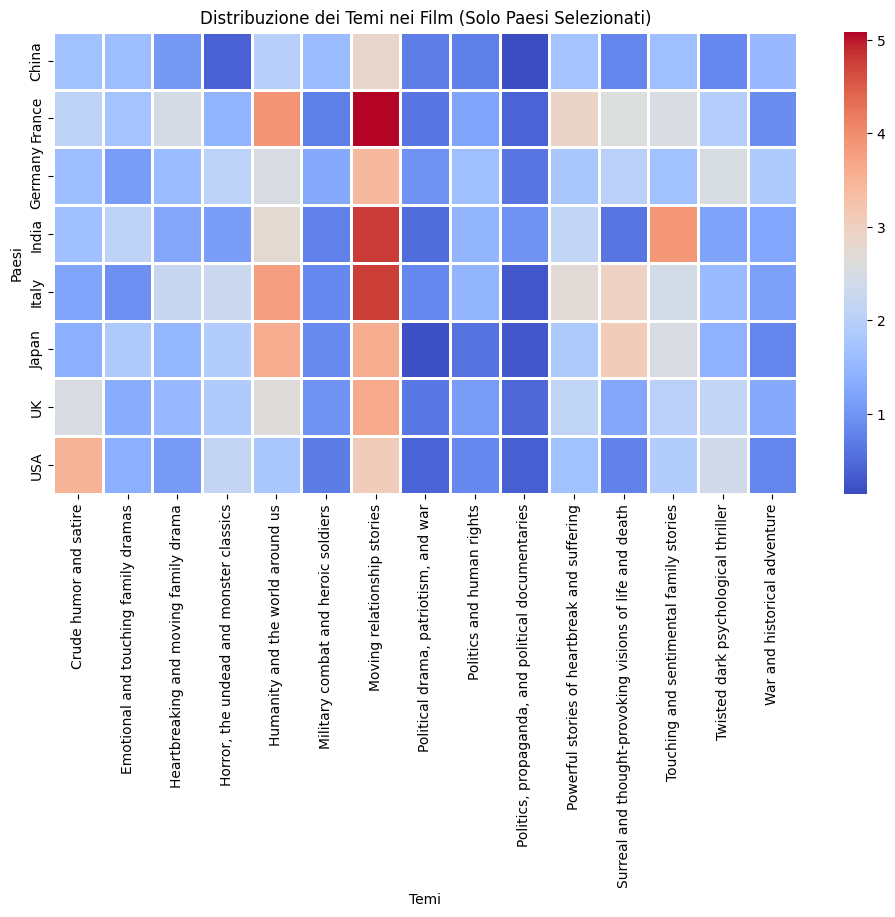

In [133]:
#aggiungere eventuali paesi di interesse
paesi_interessati = ["USA", "Italy", "Germany", "France", "China", "Japan", "India", "UK"]
To_filter=theme_counts["Theme"].value_counts().nlargest(15).index
filtered_df_themes = theme_counts[theme_counts["Theme"].isin(To_filter)]

pivot_table_filtered = filtered_df_themes[filtered_df_themes["Country"].isin(paesi_interessati)] \
    .pivot(index="Country", columns="Theme", values="Percentage")

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table_filtered, cmap="coolwarm", linewidths=1, fmt=".1f")
plt.title("Distribuzione dei Temi nei Film (Solo Paesi Selezionati)")
plt.xlabel("Temi")
plt.ylabel("Paesi")
plt.show()

Abbiamo scelto di prendere solo certi paesi in considerazione, per non saturare la tabella, ma avere comunque una buona idea generale dei temi e della loro dispersione.
Possiamo cosi nottare che ci sono temi più prevalenti nei paesi, ma molti di questi si bilanciano in quantità, non evidenziandone la loro importanza, rispetto ad altri che cadono subito all'occhio.
Possiamo notare chiaramente che il genere "Moving relationship stories" è presente in tutti i paesi, durante lo sviluppo negli anni.


Ora sviluppiamo dei grafici per notare se vi sono delle tendenze durante gli anni, per provare ad associarli ad eventuali eventi storici. Prenderemo in considerazione soltanto alcuni paesi.


In [134]:
filtered_trends = df_releases.merge(df_themes, on="id_film", how="inner")[["date", "country", "theme"]]
filtered_trends = filtered_trends[filtered_trends["country"].isin(paesi_interessati)]

filtered_trends_grouped = filtered_trends.groupby(["date", "country", "theme"]).size().reset_index(name="count")

top_themes = filtered_trends_grouped.groupby("theme")["count"].sum().nlargest(3).index
filtered_trends_grouped = filtered_trends_grouped[filtered_trends_grouped["theme"].isin(top_themes)]



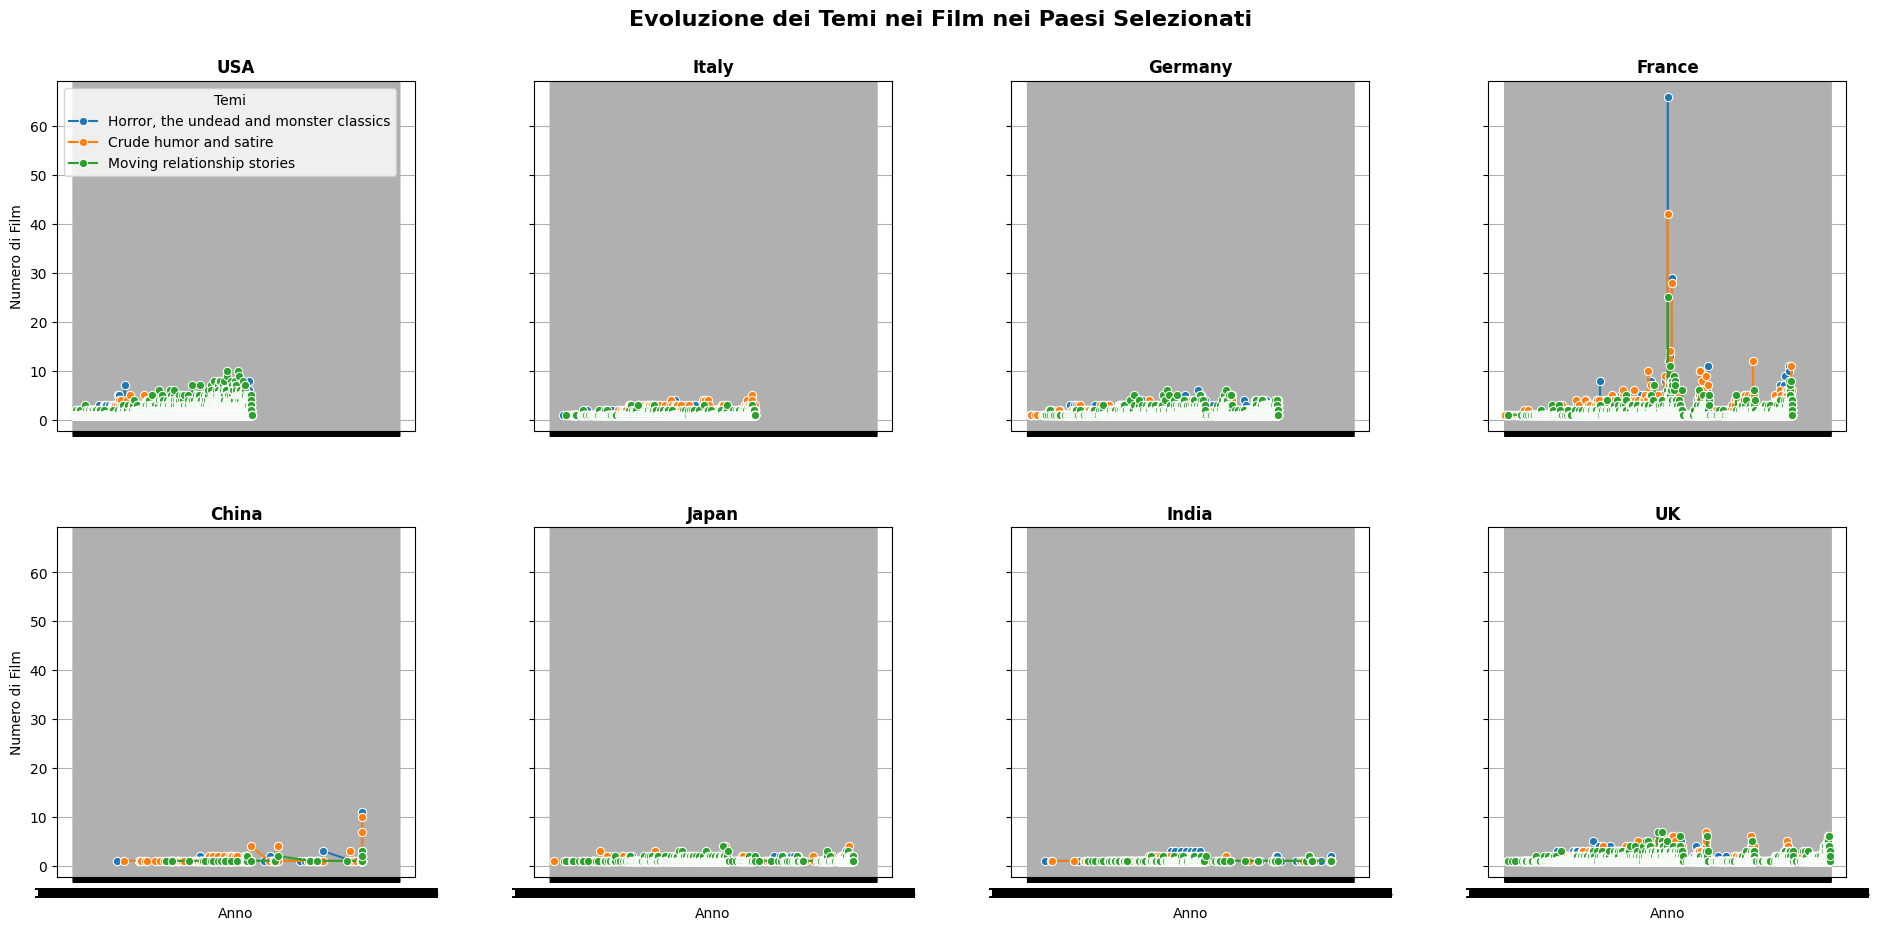

In [135]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10), sharex=True, sharey=True)
axes = axes.flatten()
for i, country in enumerate(paesi_interessati):
    ax = axes[i]
    country_data = filtered_trends_grouped[filtered_trends_grouped["country"] == country]

    sns.lineplot(
        data=country_data, 
        x="date", 
        y="count", 
        hue="theme", 
        marker="o", 
        ax=ax
    )
    ax.set_title(f"{country}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Anno")
    ax.set_ylabel("Numero di Film")
    ax.grid(True)
    
    if i == 0:
        ax.legend(title="Temi", loc="upper left")
    else:
        ax.legend().remove()

plt.tight_layout(pad=5.0)  
plt.suptitle("Evoluzione dei Temi nei Film nei Paesi Selezionati", fontsize=16, fontweight="bold")

plt.subplots_adjust()
plt.show()

Possiamo vedere come questi siano i 3 generi maggiormente presenti all'interno di questi paesi.Vediamo una dominanza del genere drammatico, accompagnato agli altri 2.
Vediamo chiaramente come in tutti i paesi, Gli horror e i satirici sono prevalenti agli inizi di ogni grafico, per poi evolversi in "Moving relationship stories".


Vediamo ora lo sviluppo di determinati temi in diversi continenti.


In [136]:
total_trends=filtered_trends
total_trends = total_trends[["date", "country", "theme"]] 
total_trends.head()

,date,country,theme
104,2023-07-21,China,Humanity and the world around us
105,2023-07-21,China,Crude humor and satire
106,2023-07-21,China,Moving relationship stories
107,2023-07-21,China,Emotional and captivating fantasy storytelling
108,2023-07-21,China,Surreal and thought-provoking visions of life ...


In [137]:
continents = {
    "Europe": ["France", "Germany", "Italy", "Spain", "UK"],
    "North America": ["USA", "Canada"],
    "Asia": ["China", "Japan", "India"]
}

total_trends["continent"] = total_trends["country"].map(
    lambda x: next((k for k, v in continents.items() if x in v), "Other")
)
total_trends_Filtered = total_trends[total_trends["continent"] != "Other"]
total_trends_Filtered.head()

,date,country,theme,continent
104,2023-07-21,China,Humanity and the world around us,Asia
105,2023-07-21,China,Crude humor and satire,Asia
106,2023-07-21,China,Moving relationship stories,Asia
107,2023-07-21,China,Emotional and captivating fantasy storytelling,Asia
108,2023-07-21,China,Surreal and thought-provoking visions of life ...,Asia


In [138]:
df_themes["theme"].unique()

array(['Humanity and the world around us', 'Crude humor and satire',
       'Moving relationship stories',
       'Emotional and captivating fantasy storytelling',
       'Surreal and thought-provoking visions of life and death',
       'Quirky and endearing relationships',
       'Amusing jokes and witty satire',
       'Laugh-out-loud relationship entanglements',
       'Intense violence and sexual transgression',
       'Twisted dark psychological thriller',
       'Heartbreaking and moving family drama',
       'Enduring stories of family and marital drama',
       'Touching and sentimental family stories',
       'Intense political and terrorist thrillers',
       'Powerful stories of heartbreak and suffering',
       'Dreamlike, quirky, and surreal storytelling',
       'Challenging or sexual themes & twists',
       'Graphic violence and brutal revenge', 'Song and dance',
       'Dazzling vocal performances and musicals',
       'Captivating relationships and charming romance',


Ora possiamo analizzare la distribuzione dei film storici in Europa


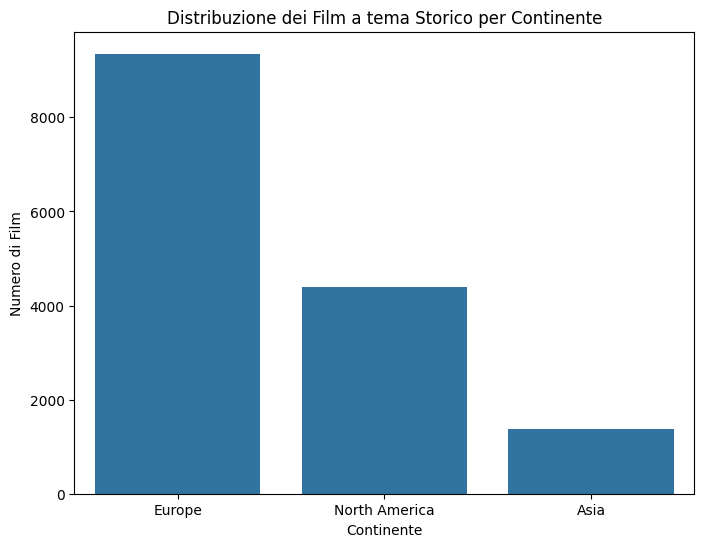

In [139]:
historical_films = total_trends_Filtered[(total_trends_Filtered["theme"] == "Historical battles and epic heroism") |
                             (total_trends_Filtered["theme"] == "Nazis and World War II") | 
                             (total_trends_Filtered["theme"] == "War and historical adventure") | 
                             (total_trends_Filtered["theme"] == "Bravery in War" )]

historical_counts = historical_films["continent"].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=historical_counts.index, y=historical_counts.values)
plt.xlabel("Continente")
plt.ylabel("Numero di Film")
plt.title("Distribuzione dei Film a tema Storico per Continente")
plt.show()

Notiamo che chiaramente i film storici sono molto più presenti in europa rispetto che in Nord America o in Asia.
Questo sicuramente influenzato dalle numerose guerre che si sono svolte in questo territorio durante gli anni e quindi ai molti film storici rilasciati nel continente.


Analiziamo ora i film di azione per vedere se sono di numero maggiore in America rispetto agli altri continenti presi in considerazione.


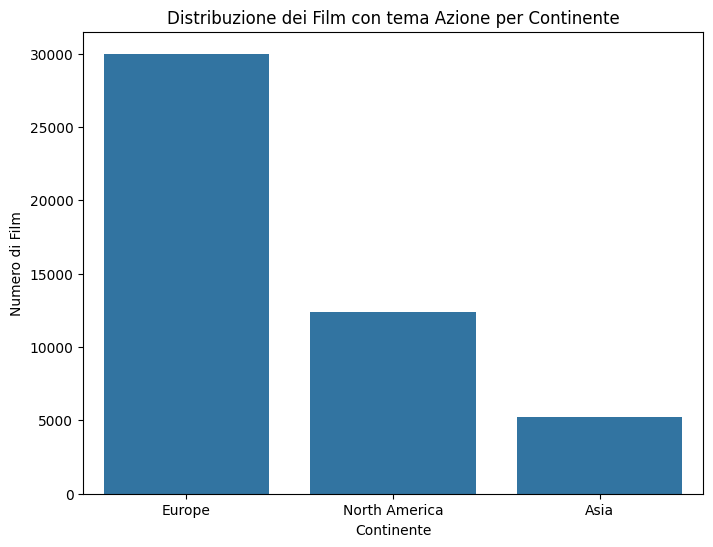

In [140]:
action_films = total_trends_Filtered[(total_trends_Filtered["theme"] == "Action-packed space and alien sagas") |
                             (total_trends_Filtered["theme"] == "Thought-provoking sci-fi action and future technology") | 
                             (total_trends_Filtered["theme"] == "Superheroes in action-packed battles with villains") | 
                             (total_trends_Filtered["theme"] == "Violent action, guns, and crime" ) |
                             (total_trends_Filtered["theme"] == "Heists and thrilling action") |
                             (total_trends_Filtered["theme"] == "Explosive and action-packed heroes vs. villains") |
                             (total_trends_Filtered["theme"] == "Adrenaline-fueled action and fast cars")
                             ]

action_counts = action_films["continent"].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=action_counts.index, y=action_counts.values)
plt.xlabel("Continente")
plt.ylabel("Numero di Film")
plt.title("Distribuzione dei Film con tema Azione per Continente")
plt.show()

Anche se rispetto ai film storici vi è un numero maggiore di film rilasciati, in Europa i film di azione hanno un numero maggiore rispetto a quelli rilasciati in America. Quindi anche se una maggiore produttrice di film di questo tema, comunque non vi è la superiorità sui rilasci.


Vediamo ora se la fantascienza durante gli anni ha un grafico in crescita e quindi si è sviluppata con il tempo.


In [141]:
sci_fi_asia = total_trends_Filtered[((total_trends_Filtered["theme"] == "Monsters, aliens, sci-fi and the apocalypse") |
                             (total_trends_Filtered["theme"] == "Imaginative space odysseys and alien encounters") | 
                             (total_trends_Filtered["theme"] == "Thought-provoking sci-fi action and future technology") | 
                             (total_trends_Filtered["theme"] == "Sci-fi horror, creatures, and aliens" ) |
                             (total_trends_Filtered["theme"] == "Sci-fi monster and dinosaur adventures"))
                             & (total_trends_Filtered["continent"] == "Asia")]

sci_fi_asia_trend = sci_fi_asia.groupby("date").size().reset_index(name="count")

print(sci_fi_asia_trend.shape)
print (sci_fi_asia_trend.head())

(958, 2)
         date  count
0  1905-08-08      4
1  1929-04-03      1
2  1953-09-01      4
3  1954-10-27      3
4  1954-11-03      3


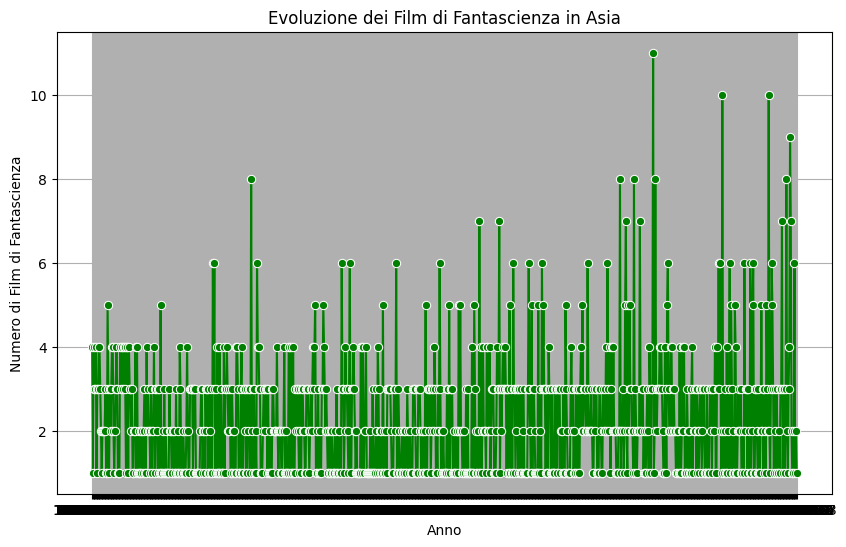

In [142]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=sci_fi_asia_trend, x="date", y="count",marker="o", color="green")
plt.xlabel("Anno")
plt.ylabel("Numero di Film di Fantascienza")
plt.title("Evoluzione dei Film di Fantascienza in Asia")
plt.grid(True)
plt.show()

Notiamo che il grafico è in leggera crescita nel tempo, quindi possiamo stabilire che il genere Sci-Fi si stia sviluppando sempre di più durante gli anni, con un evidente punto di interesse in Asia visto il numero elevato di film rilasciati.


### Risultato analisi:

Abbiamo analizzato il trend dei temi ........................................................................

Infine abbiamo risposto ai quesiti, stabilendo che l'Europa è un continente considerato un grande centro di rilascio di film, notando una prevalenza di film storici. Abbiamo constatato anche pur essendo uno dei produttori di film maggiore al mondo, l'America non ha il vantaggio di numero di film rilasciati nel paese a tema "Azione".
L'Asia invece si proclama come centro di sviluppo del tema "Sci-Fi", seguendo la sua cultura fantascientifica di robot, tecnologia futura ed evoluzione umana.
